In [76]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
colors = plt.get_cmap('tab10').colors

In [86]:
metrics = [r"Δe", r"Δa", r"Δ⍵", r"ΔM"]
data = np.genfromtxt('out.txt', delimiter='\t', usecols=range(1, 2+8*len(metrics))) 
labels = np.genfromtxt('out.txt', delimiter='\t', usecols=0, dtype=str)
runtimes = data[:,0]
N = data.shape[0]
metric_data = data[:,1:].reshape((-1,8,len(metrics)))
metric_data.shape

(2336, 8, 4)

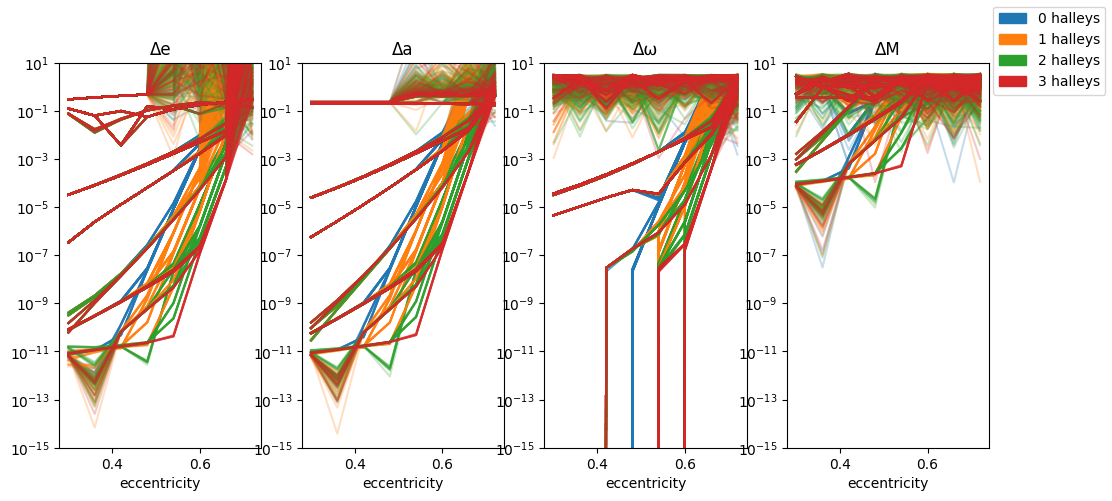

In [89]:
fig, ax = plt.subplots(1,len(metrics),sharex=True,figsize=(12,5))
es = np.linspace(0.3,0.72,8,endpoint=True)
for j,m in enumerate(metrics):
    ax[j].set_yscale("log")
    ax[j].set_xlabel("eccentricity")
    ax[j].set_title(m)
    ax[j].set_ylim([1e-15,1e1])
    for i in range(N):
        stages = labels[i].count("stiefel")-1
        if stages ==3:
            halleys = labels[i].count("halley")

            ax[j].plot(es, np.abs(metric_data[i,:,j]),label=(labels[i] + " %.3fs"%runtimes[i] if j==0 else None), color=colors[halleys],alpha=0.25)
handles = []
for stages in range(0,4):
    handles.append(mpatches.Patch(color=colors[stages], label='%d halleys'%stages))


# Pass the handles to the legend
fig.legend(handles=handles);
#fig.legend()